In [ ]:
# ===============================================
# STEP 0: Install / import libraries
# ===============================================

# ✅ Do NOT specify TensorFlow version (use preinstalled 2.19.0)
!pip install -q matplotlib tqdm pillow seaborn

import os, zipfile, math, random, pathlib
from glob import glob
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("✅ TensorFlow version:", tf.__version__)


✅ TensorFlow version: 2.19.0


In [ ]:
# ===============================================
# STEP 2: Load and Inspect Dataset
# ===============================================

from google.colab import drive
drive.mount('/content/drive')

# ✅ Path to your dataset zip file (change path if needed)
ZIP_PATH = '/content/drive/MyDrive/ML-datasets/gzip.zip'  # <-- replace with your actual zip path

# ✅ Create extraction directory
EXTRACT_DIR = '/content/handwritten_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

# ✅ Extract zip file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print(f"✅ Extracted dataset to: {EXTRACT_DIR}")

# ===============================================
# STEP 3: Explore files
# ===============================================
from glob import glob

csv_files = glob(os.path.join(EXTRACT_DIR, '**', '*.csv'), recursive=True)
npz_files = glob(os.path.join(EXTRACT_DIR, '**', '*.npz'), recursive=True)
npy_files = glob(os.path.join(EXTRACT_DIR, '**', '*.npy'), recursive=True)
img_dirs = [p for p in glob(os.path.join(EXTRACT_DIR, '**'), recursive=True) if os.path.isdir(p)]

print(f"CSV files: {csv_files}")
print(f"NPZ files: {npz_files}")
print(f"NPY files: {npy_files}")
print(f"Image folders: {img_dirs[:5]}")  # show only a few


Mounted at /content/drive
✅ Extracted dataset to: /content/handwritten_data
CSV files: []
NPZ files: []
NPY files: []
Image folders: ['/content/handwritten_data/', '/content/handwritten_data/gzip']


In [ ]:
# ===============================================
# STEP 2: Extract Dataset (Fixed for image folders)
# ===============================================

import zipfile, os
from glob import glob

DATASET_PATH = '/content/drive/MyDrive/your_dataset.zip'  # update if needed
EXTRACT_DIR = '/content/handwritten_data'

# ✅ Extract if not already
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"✅ Extracted dataset to: {EXTRACT_DIR}")
else:
    print("✅ Dataset already extracted")

# ✅ Check content
all_items = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for d in dirs:
        all_items.append(os.path.join(root, d))
    for f in files:
        all_items.append(os.path.join(root, f))

print("Total items found:", len(all_items))
print("Sample paths:", all_items[:5])


✅ Dataset already extracted
Total items found: 31
Sample paths: ['/content/handwritten_data/gzip', '/content/handwritten_data/gzip/emnist-bymerge-train-labels-idx1-ubyte.gz', '/content/handwritten_data/gzip/emnist-digits-test-labels-idx1-ubyte.gz', '/content/handwritten_data/gzip/emnist-balanced-train-labels-idx1-ubyte.gz', '/content/handwritten_data/gzip/emnist-letters-test-labels-idx1-ubyte.gz']


In [ ]:
import os

EXTRACT_DIR = "/content/handwritten_data"
for root, dirs, files in os.walk(EXTRACT_DIR):
    print("📁", root)
    for d in dirs:
        print("  ┣━", d)
    for f in files[:10]:  # show only first few files
        print("  ┗━", f)
    print("-" * 40)


📁 /content/handwritten_data
  ┣━ gzip
----------------------------------------
📁 /content/handwritten_data/gzip
  ┗━ emnist-bymerge-train-labels-idx1-ubyte.gz
  ┗━ emnist-digits-test-labels-idx1-ubyte.gz
  ┗━ emnist-balanced-train-labels-idx1-ubyte.gz
  ┗━ emnist-letters-test-labels-idx1-ubyte.gz
  ┗━ emnist-mnist-mapping.txt
  ┗━ emnist-mnist-test-labels-idx1-ubyte.gz
  ┗━ emnist-mnist-test-images-idx3-ubyte.gz
  ┗━ emnist-balanced-test-labels-idx1-ubyte.gz
  ┗━ emnist-letters-mapping.txt
  ┗━ emnist-byclass-test-images-idx3-ubyte.gz
----------------------------------------


In [ ]:
import gzip
import numpy as np
import os

EXTRACT_DIR = "/content/handwritten_data/gzip"

# Helper functions to load IDX format (used by MNIST/EMNIST)
def load_idx_images(file_path):
    with gzip.open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    # Each image is 28x28
    data = data.reshape(-1, 28, 28, 1)
    return data

def load_idx_labels(file_path):
    with gzip.open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

# Detect train/test files (EMNIST MNIST variant)
train_images_path = os.path.join(EXTRACT_DIR, "emnist-mnist-train-images-idx3-ubyte.gz")
train_labels_path = os.path.join(EXTRACT_DIR, "emnist-mnist-train-labels-idx1-ubyte.gz")
test_images_path = os.path.join(EXTRACT_DIR, "emnist-mnist-test-images-idx3-ubyte.gz")
test_labels_path = os.path.join(EXTRACT_DIR, "emnist-mnist-test-labels-idx1-ubyte.gz")

# Load them
if os.path.exists(train_images_path):
    X_train = load_idx_images(train_images_path)
    y_train = load_idx_labels(train_labels_path)
    X_test = load_idx_images(test_images_path)
    y_test = load_idx_labels(test_labels_path)
else:
    raise FileNotFoundError("Expected EMNIST-MNIST gzip files not found in folder.")

print(f"✅ Loaded train shape: {X_train.shape}, test shape: {X_test.shape}")
print(f"✅ Labels: {len(np.unique(y_train))} unique classes")


✅ Loaded train shape: (60000, 28, 28, 1), test shape: (10000, 28, 28, 1)
✅ Labels: 10 unique classes


In [ ]:
# ===============================================
# STEP 4: Data augmentation (ImageDataGenerator)
# ===============================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Split train into (train + validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

num_classes = len(np.unique(y_train))
BATCH_SIZE = 128

# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.05,
    zoom_range=0.08
)

# Validation/test sets should not be augmented
val_datagen = ImageDataGenerator()

# One-hot encode labels for categorical crossentropy
train_gen = train_datagen.flow(
    X_train,
    tf.keras.utils.to_categorical(y_train, num_classes),
    batch_size=BATCH_SIZE
)

val_gen = val_datagen.flow(
    X_val,
    tf.keras.utils.to_categorical(y_val, num_classes),
    batch_size=BATCH_SIZE
)

print(f"✅ Train batches: {len(train_gen)}, Val batches: {len(val_gen)}")
print(f"Input shape: {X_train.shape[1:]}, Num classes: {num_classes}")


✅ Train batches: 422, Val batches: 47
Input shape: (28, 28, 1), Num classes: 10


In [ ]:
# ===============================================
# STEP 5: Build the CNN model (for handwritten character recognition)
# ===============================================
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    # Convolutional block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Flatten + dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,954 (949.04 KB)

 Trainable params: 242,250 (946.29 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# ===============================================
# STEP 6: Train the model with callbacks
# ===============================================
EPOCHS = 5
callbacks_list = [
    callbacks.ModelCheckpoint('/content/best_hwr_model.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    steps_per_epoch=math.ceil(len(X_train)/BATCH_SIZE),
    validation_steps=math.ceil(len(X_val)/BATCH_SIZE)
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 89s 212ms/step - accuracy: 0.9810 - loss: 0.0653 - val_accuracy: 0.9912 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 89s 212ms/step - accuracy: 0.9844 - loss: 0.0516 - val_accuracy: 0.9865 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 209ms/step - accuracy: 0.9862 - loss: 0.0481 - val_accuracy: 0.9918 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 95s 226ms/step - accuracy: 0.9866 - loss: 0.0430 - val_accuracy: 0.9918 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 95s 223ms/step - accuracy: 0.9890 - loss: 0.0353 - val_accuracy: 0.9830 - val_loss: 0.0513 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      0.99      0.99      1000
           2       0.98      0.99      0.99      1000
           3       0.99      1.00      0.99      1000
           4       0.99      0.99      0.99      1000
           5       0.99      0.99      0.99      1000
           6       1.00      1.00      1.00      1000
           7       0.99      1.00      0.99      1000
           8       1.00      0.97      0.99      1000
           9       0.99      0.99      0.99      1000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



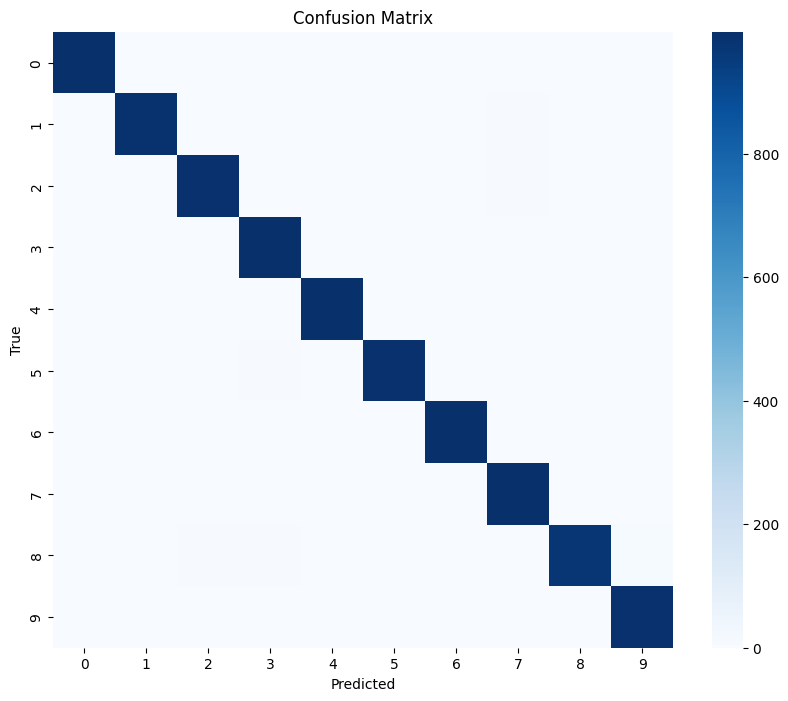

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# ✅ Use numeric labels for 0-9 digits
target_names = [str(i) for i in range(num_classes)]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion matrix (plot)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


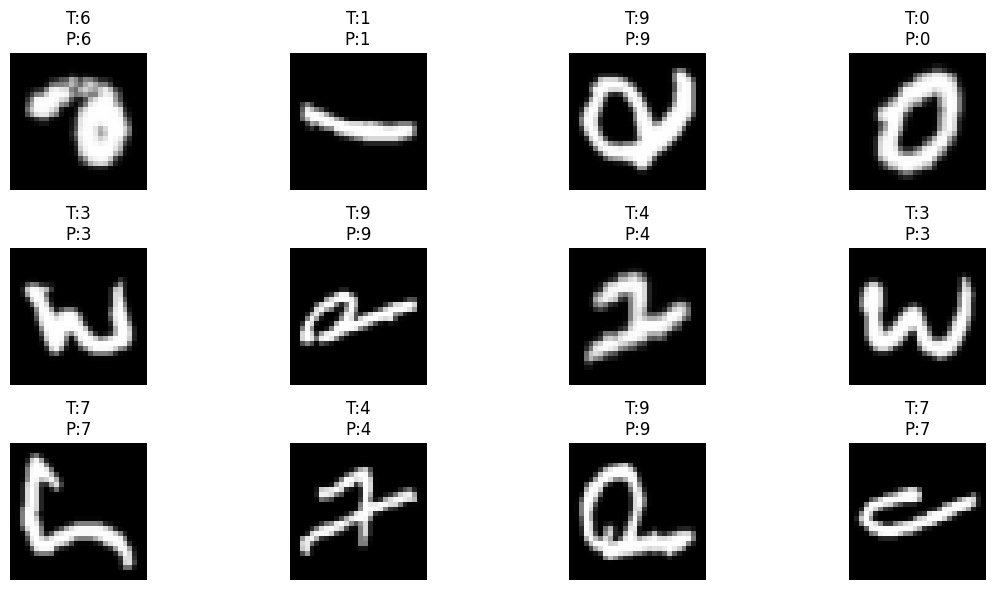

In [ ]:
# ===============================================
# STEP 8: Show sample predictions (Fixed)
# ===============================================

def show_samples(X, y_true, y_pred, classes, n=12):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(idxs):
        plt.subplot(3,4,i+1)
        img = X[idx].reshape(IMG_SIZE, IMG_SIZE)
        plt.imshow(img, cmap='gray')
        plt.title(f"T:{classes[y_true[idx]]}\nP:{classes[y_pred[idx]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ✅ Since EMNIST/MNIST has 10 digits
classes = [str(i) for i in range(num_classes)]

show_samples(X_test, y_test, y_pred, classes, n=12)


In [ ]:
# ===============================================
# STEP 9: Save artifacts (model + label encoder)
# ===============================================
import joblib
best.save('/content/final_hwr_model.keras')   # final model saved
joblib.dump(le, '/content/label_encoder_hwr.pkl')
print("Saved model and label encoder to /content/")


Saved model and label encoder to /content/
